<a href="https://colab.research.google.com/github/greinaldi/repositorio/blob/main/redesNeurais_Keras/redesNeurais_Keras_classificacao_BalanceScale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Classificação com Keras usando o conjunto de dados Balance Scale

Link: https://archive.ics.uci.edu/dataset/12/balance+scale

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.optimizers import Adam

In [2]:
# Leitura do dataset
dados = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data',
                    names=['Class', 'Left-weight', 'Left-distance', 'Right-weight', 'Right-distance'])

In [3]:
# Visualização do dataset
dados.head()

,Class,Left-weight,Left-distance,Right-weight,Right-distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5


In [4]:
# Definição dos atributos preditores e classe
x = dados.drop(columns=['Class'])
y = dados['Class']

In [5]:
y.value_counts()

,count
Class,
R,288
L,288
B,49


In [6]:
# Substituição dos valores de y para valores numéricos
y.replace('L', 0, inplace=True)
y.replace('R', 1, inplace=True)
y.replace('B', 2, inplace=True)

/tmp/ipython-input-34069168.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace('B', 2, inplace=True)


In [7]:
# Separação em bases de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, stratify=y)

In [8]:
# Dimensões dos dados
x_treino.shape, x_teste.shape, y_treino.shape, y_teste.shape

((500, 4), (125, 4), (500,), (125,))

In [9]:
# Conversão de y para matriz de três classes
y_treino_convertido = tf.keras.utils.to_categorical(y_treino)
y_teste_convertido = tf.keras.utils.to_categorical(y_teste)

In [10]:
# Matrizes convertidas de y: visualização
"Treino:", y_treino_convertido[0:5], "\n Teste:", y_teste_convertido[0:5]

('Treino:',
 array([[0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.]]),
 '\n Teste:',
 array([[1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]]))

In [11]:
# Definição de modelo
modelo = Sequential()

# 1ª Camada oculta: entrada dos dados
modelo.add(Dense(40, input_dim=4, kernel_initializer='normal', activation='relu'))
modelo.add(Dropout(0.3))

# 2ª Camada oculta
modelo.add(Dense(40, kernel_initializer='normal', activation='relu'))
modelo.add(Dropout(0.3))

# Camada de saída
modelo.add(Dense(3, kernel_initializer='normal', activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Otimizador
otimizador = Adam()

In [13]:
# Função de custo, otimizador e métrica de avaliação
modelo.compile(loss='categorical_crossentropy', optimizer=otimizador, metrics=['acc'])

In [14]:
# Treinamento do modelo
historico = modelo.fit(x_treino, y_treino_convertido, batch_size=500, epochs=1000, validation_data=(x_teste, y_teste_convertido))

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.4460 - loss: 1.0968 - val_acc: 0.6000 - val_loss: 1.0941
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - acc: 0.5540 - loss: 1.0927 - val_acc: 0.7360 - val_loss: 1.0908
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.6280 - loss: 1.0892 - val_acc: 0.7520 - val_loss: 1.0873
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - acc: 0.6380 - loss: 1.0855 - val_acc: 0.7520 - val_loss: 1.0836
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - acc: 0.6740 - loss: 1.0820 - val_acc: 0.7760 - val_loss: 1.0796
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - acc: 0.6900 - loss: 1.0786 - val_acc: 0.8000 - val_loss: 1.0755
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - acc: 0.7000 - loss: 1.0745 - val_acc: 0.8160 - val_loss: 1.0712
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - acc: 0.7080 - loss: 1.0694 - val_acc: 0.8240 - val_loss: 1.0667
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - acc: 0

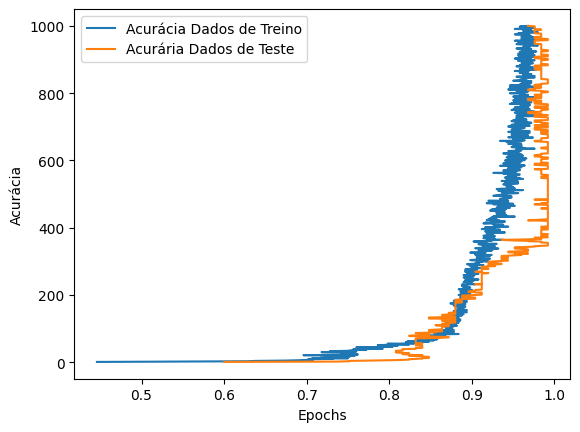

In [15]:
# Gráfico da acurácia dos modelos de treino e teste

# Eixos y
acuracia_treino = historico.history['acc']
acuracia_teste = historico.history['val_acc']

# Eixo x
epochs = range(1, len(acuracia_treino)+1)

plt.plot(acuracia_treino, epochs, label='Acurácia Dados de Treino')
plt.plot(acuracia_teste, epochs, label='Acurária Dados de Teste')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acurácia')
plt.show()

In [16]:
# Previsões
predicoes = modelo.predict(x_teste)
print(predicoes)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[9.9999553e-01 1.0355809e-12 4.4345484e-06]
 [9.2835057e-01 1.0812446e-03 7.0568249e-02]
 [5.7905809e-16 9.9999994e-01 2.4654348e-08]
 [3.1162808e-10 9.9997801e-01 2.1945871e-05]
 [1.4035511e-03 9.5335221e-01 4.5244243e-02]
 [2.8567181e-05 9.9179131e-01 8.1800707e-03]
 [1.2410708e-19 9.9999994e-01 3.0802422e-10]
 [1.5532813e-11 9.9999708e-01 2.8842005e-06]
 [9.9999982e-01 6.3220226e-16 6.8879849e-08]
 [9.9999899e-01 8.9158912e-14 9.8755606e-07]
 [9.9997407e-01 2.8540961e-10 2.5818903e-05]
 [4.7147337e-01 3.9953988e-02 4.8857272e-01]
 [9.9988478e-01 7.3159773e-10 1.1513257e-04]
 [9.6426988e-01 2.4472993e-05 3.5705473e-02]
 [9.9829412e-01 1.7727648e-07 1.7057409e-03]
 [2.3251923e-16 9.9999994e-01 1.5231256e-08]
 [9.9998599e-01 4.2241911e-11 1.3952336e-05]
 [9.9999970e-01 1.5517373e-14 2.6220383e-07]
 [3.3099368e-06 9.9748194e-01 2.5146897e-03]
 [9.9902254e-01 3.8402592e-07 9.7708660e-04]
 [2.3109973e-13 9.9999934e-01 6.0821748e-07]
 [1.1475617e-09 9

In [17]:
np.set_printoptions(formatter={'float': lambda x: "{0:0.2f}".format(x)})
print(predicoes)

[[1.00 0.00 0.00]
 [0.93 0.00 0.07]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [0.00 0.95 0.05]
 [0.00 0.99 0.01]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [1.00 0.00 0.00]
 [1.00 0.00 0.00]
 [1.00 0.00 0.00]
 [0.47 0.04 0.49]
 [1.00 0.00 0.00]
 [0.96 0.00 0.04]
 [1.00 0.00 0.00]
 [0.00 1.00 0.00]
 [1.00 0.00 0.00]
 [1.00 0.00 0.00]
 [0.00 1.00 0.00]
 [1.00 0.00 0.00]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [0.00 0.97 0.03]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [0.18 0.14 0.68]
 [1.00 0.00 0.00]
 [0.19 0.14 0.68]
 [0.00 1.00 0.00]
 [1.00 0.00 0.00]
 [0.00 1.00 0.00]
 [0.07 0.14 0.78]
 [0.96 0.00 0.04]
 [0.95 0.00 0.05]
 [0.95 0.00 0.04]
 [0.00 0.99 0.01]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [0.02 0.60 0.38]
 [0.00 1.00 0.00]
 [1.00 0.00 0.00]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [1.00 0.00 0.00]
 [0.00 0.97 0.03]
 [0.00 1.00 0.00]
 [0.00 1.00 0.00]
 [1.00 0.00 0.00]
 [0.03 0.58 0.40]
 [1.00 0.00 0.00]
 [1.00 0.00 0.00]
 [0.21 0.09 0.71]
 [0.08 0.16 0.76]
 [0.96 0.0